In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("fake_reviews_dataset.csv")
df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [2]:
print(df.shape)
print(df.columns.tolist())
print(df['label'].value_counts())

(40432, 4)
['category', 'rating', 'label', 'text_']
label
CG    20216
OR    20216
Name: count, dtype: int64


In [3]:
# Label'ı sayısala çevir: OR=1 (gerçek), CG=0 (sahte)
df['label'] = df['label'].map({'OR': 1, 'CG': 0})

print(df['label'].value_counts())
print("\n")
print(df.isnull().sum())

label
0    20216
1    20216
Name: count, dtype: int64


category    0
rating      0
label       0
text_       0
dtype: int64


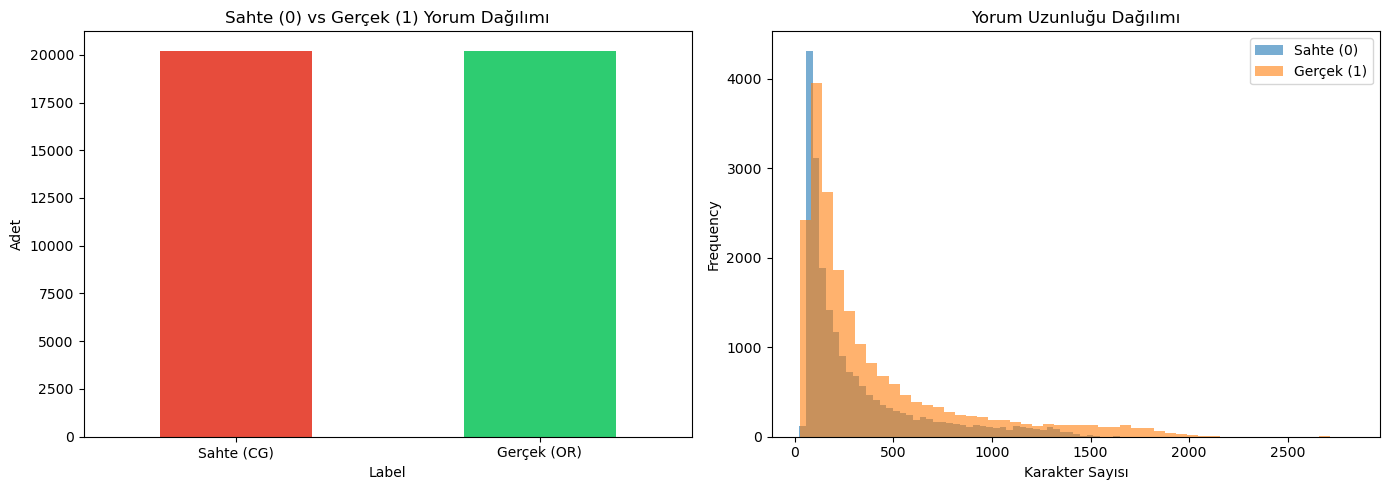

In [4]:
# Yorum uzunluklarını ekleyelim
df['review_length'] = df['text_'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sahte vs Gerçek dağılımı
df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Sahte (0) vs Gerçek (1) Yorum Dağılımı')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Adet')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Sahte (CG)', 'Gerçek (OR)'], rotation=0)

# Yorum uzunluğu dağılımı
df.groupby('label')['review_length'].plot(kind='hist', bins=50, alpha=0.6, ax=axes[1], legend=True)
axes[1].set_title('Yorum Uzunluğu Dağılımı')
axes[1].set_xlabel('Karakter Sayısı')
axes[1].legend(['Sahte (0)', 'Gerçek (1)'])

plt.tight_layout()
plt.show()

In [17]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

print("Kütüphaneler hazırrrrrrrrr!")

Kütüphaneler hazırrrrrrrrr!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Mel\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Mel\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Mel\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [6]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Küçük harfe çevir
    text = text.lower()
    # Sayı ve özel karakterleri kaldır
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize et
    tokens = text.split()
    # Stop-word temizliği + Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Temizlenmiş metni yeni sütuna ekle
df['clean_text'] = df['text_'].apply(clean_text)

# Sonucu göster
print("Orijinal:", df['text_'][0][:100])
print("Temizlenmiş:", df['clean_text'][0][:100])

Orijinal: Love this!  Well made, sturdy, and very comfortable.  I love it!Very pretty
Temizlenmiş: love well made sturdy comfortable love itvery pretty


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# TF-IDF
tfidf = TfidfVectorizer(max_features=10000)
X = tfidf.fit_transform(df['clean_text'])
y = df['label']

# Train/Test split (%80 eğitim, %20 test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Eğitim seti:", X_train.shape)
print("Test seti:", X_test.shape)

Eğitim seti: (32345, 10000)
Test seti: (8087, 10000)


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Modeli kur ve eğit
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Tahmin
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]

# Sonuçlar
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred, target_names=['Sahte (0)', 'Gerçek (1)']))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))

=== Logistic Regression ===
              precision    recall  f1-score   support

   Sahte (0)       0.88      0.86      0.87      4044
  Gerçek (1)       0.86      0.88      0.87      4043

    accuracy                           0.87      8087
   macro avg       0.87      0.87      0.87      8087
weighted avg       0.87      0.87      0.87      8087

ROC-AUC: 0.9441


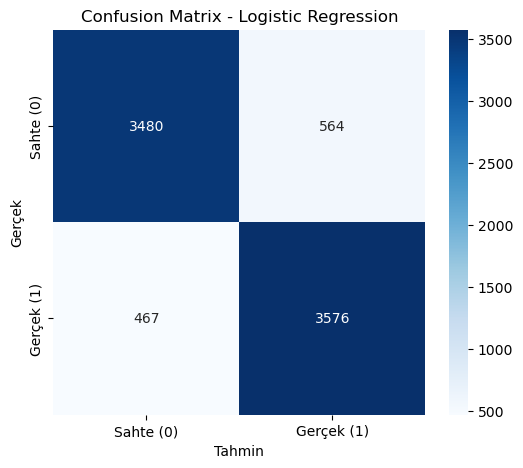

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sahte (0)', 'Gerçek (1)'],
            yticklabels=['Sahte (0)', 'Gerçek (1)'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.show()

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['Sahte (0)', 'Gerçek (1)']))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))

=== Random Forest ===
              precision    recall  f1-score   support

   Sahte (0)       0.83      0.89      0.86      4044
  Gerçek (1)       0.88      0.81      0.84      4043

    accuracy                           0.85      8087
   macro avg       0.85      0.85      0.85      8087
weighted avg       0.85      0.85      0.85      8087

ROC-AUC: 0.9276


In [11]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm_model = LinearSVC(max_iter=1000, random_state=42)
svm_model = CalibratedClassifierCV(svm_model)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

print("=== SVM ===")
print(classification_report(y_test, y_pred_svm, target_names=['Sahte (0)', 'Gerçek (1)']))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_svm), 4))

=== SVM ===
              precision    recall  f1-score   support

   Sahte (0)       0.87      0.88      0.88      4044
  Gerçek (1)       0.88      0.87      0.88      4043

    accuracy                           0.88      8087
   macro avg       0.88      0.88      0.88      8087
weighted avg       0.88      0.88      0.88      8087

ROC-AUC: 0.9504


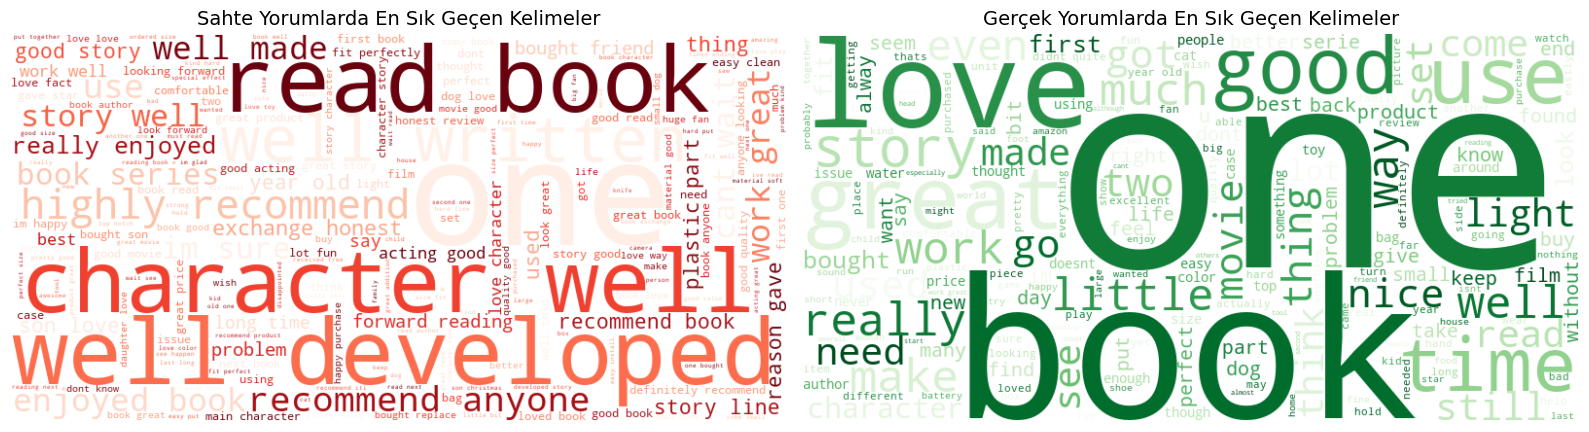

In [12]:
from wordcloud import WordCloud

# Sahte yorumların metinleri
fake_text = ' '.join(df[df['label'] == 0]['clean_text'])
# Gerçek yorumların metinleri
real_text = ' '.join(df[df['label'] == 1]['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sahte yorum WordCloud
wc_fake = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(fake_text)
axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].set_title('Sahte Yorumlarda En Sık Geçen Kelimeler', fontsize=14)
axes[0].axis('off')

# Gerçek yorum WordCloud
wc_real = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(real_text)
axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].set_title('Gerçek Yorumlarda En Sık Geçen Kelimeler', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


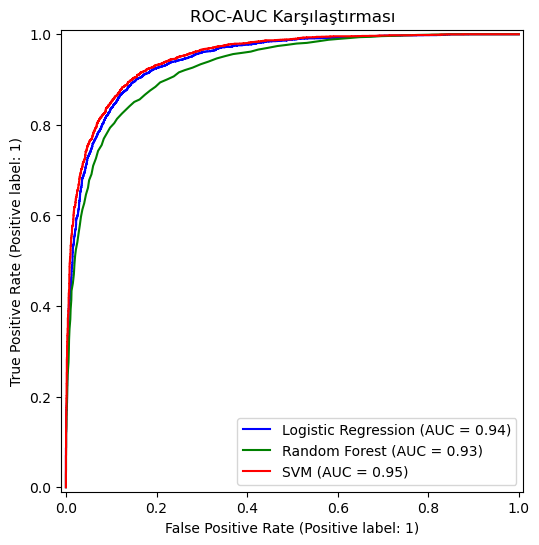

In [18]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, y_prob, name="Logistic Regression", ax=ax, color='blue')
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="Random Forest", ax=ax, color='green')
RocCurveDisplay.from_predictions(y_test, y_prob_svm, name="SVM", ax=ax, color='red')

ax.set_title('ROC-AUC Karşılaştırması')
plt.show()

In [19]:
import pickle

# SVM modelini kaydet
with open('model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)

# TF-IDF'i kaydet
with open('tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Model ve TF-IDF kaydedildi!")

Model ve TF-IDF kaydedildi!
